# r/homeless

#### Reddit group description:

A "home" for the homeless.
This group is for advice and to share experiences and stories of homelessness. We are a tight knit community made up of formerly homeless and currently homeless as well as others. NO soft begging will be tolerated here. No cash donations , No freemoney, No begging . Someone can normally answer your questions or concerns quickly and with experience. If you are currently homeless and need help or facing homelessness and have questions you found the right sub and welcome.

Created: Feb 18, 2009
Public: 74K Members

### Topic Modeling

In [1]:
import pandas as pd
import re
import gensim
import pyLDAvis
import pyLDAvis.gensim_models
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /Users/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/admin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
# Load and examine data
df = pd.read_csv('Data/reddit/homeless.csv')
print(f"Loaded {len(df)} comments")
print(f"Columns: {df.columns.tolist()}")
print(f"First few comments:")
for i in range(3):
    print(f"{i+1}: {df.iloc[i, 0][:100]}...")

Loaded 8489 comments
Columns: ['0']
First few comments:
1: Are there any homeless shelters that do not require a state photo ID to enter? Fleeing my dangerous,...
2: ##REMINDERS FOR EVERYONE

**PER THE RULES:**

* **NO OFFERINGS OF CASH, ETC.**
* **[BEGGING](https:/...
3: Anybody in Jax Florida?...


In [3]:
# Clean and prepare text
def clean_text(text):
    if not isinstance(text, str) or text in ['[deleted]', '[removed]', '']:
        return ""
    
    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove punctuation, numbers, etc.
    text = re.sub(r"[^A-Za-z\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

# Apply cleaning
comments = df.iloc[:, 0].apply(clean_text)
comments = comments[comments.str.len() > 10]  # Remove very short comments
print(f"After cleaning: {len(comments)} comments")

After cleaning: 8160 comments


In [4]:
# Tokenize and remove stopwords
swords = stopwords.words('english')

# Remove punctuation from stopwords to match your cleaned text
swords_clean = []
for word in swords:
    # Apply same cleaning as clean_text function
    clean_word = re.sub(r"[^A-Za-z\s]", "", word)
    if clean_word and len(clean_word) > 0:
        swords_clean.append(clean_word.lower())

# Remove duplicates and empty strings
swords_clean = list(set([word for word in swords_clean if word]))
swords_clean = sorted(swords_clean)

print(f"Original stopwords: {len(swords)}")
# print(swords)
print(f"Cleaned stopwords: {len(swords_clean)}")
# print(swords_clean)

# Add specific stopwords
reddit_stopwords = ['reddit', 'edit', 'update', 'deleted', 'removed', 'comment', 'post', 'thread']
additional_stopwords = ['lets', 'thats', 'people', 'even', 'time', 'way', 'thats', 'youre', 'much', 'would', 'could', 'get', 'one', 'also', 'really', 'think', 'know', 'like']

swords_clean.extend(reddit_stopwords + additional_stopwords)

print(f"Extended stopwords: {len(swords_clean)}")
# print(swords_clean)

# Tokenize
wordlists = []
for comment in comments:
    words = [word for word in word_tokenize(comment.lower()) 
            if word not in swords_clean 
            and len(word) > 0
            and word.isalpha()]
    
    wordlists.append(words)

print(f"Prepared {len(wordlists)} comments for modeling")

Original stopwords: 198
Cleaned stopwords: 196
Extended stopwords: 222
Prepared 8160 comments for modeling


In [5]:
# Analyze word frequencies
all_words = [word for wordlist in wordlists for word in wordlist]
word_freq = Counter(all_words)

print("Top 20 most common words:")
for word, freq in word_freq.most_common(20):
    print(f"{word}: {freq}")

Top 20 most common words:
homeless: 1913
help: 1105
go: 976
need: 921
good: 885
work: 775
job: 733
etc: 731
make: 727
everyone: 710
want: 710
got: 687
going: 672
please: 665
find: 632
cash: 612
children: 600
housing: 588
place: 575
money: 573


In [6]:
# Run topic model
def run_topic_model(wordlists, num_topics=4, alpha=0.7, eta=0.5):
    dictionary = gensim.corpora.Dictionary(wordlists)
    dictionary.filter_extremes(no_below=2, no_above=0.5)
    corpus = [dictionary.doc2bow(wl) for wl in wordlists]
    
    model = gensim.models.LdaMulticore(
        corpus, 
        id2word=dictionary, 
        num_topics=num_topics,
        alpha=alpha,
        eta=eta,
        random_state=1
    )
    
    return model, corpus, dictionary

# Run the model
model, corpus, dictionary = run_topic_model(wordlists, num_topics=4)


In [7]:
# Display topics
print("Topics found:")
print("=" * 50)

for idx, topic in model.show_topics(formatted=False, num_words=10):
    print(f"\nTopic {idx + 1}:")
    words = [word for word, prob in topic]
    print(f"{', '.join(words)}")


Topics found:

Topic 1:
homeless, help, need, work, make, good, find, job, want, go

Topic 2:
homeless, good, help, go, got, need, work, etc, job, want

Topic 3:
homeless, etc, go, risk, everyone, please, help, contact, work, cash

Topic 4:
homeless, help, go, need, good, going, make, us, job, housing


In [8]:
# Visualize topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(model, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.008070 -0.000790       1        1  37.261615
0      0.000381  0.003902       2        1  26.414914
2     -0.008355 -0.000556       3        1  19.912794
1     -0.000095 -0.002556       4        1  16.410676, topic_info=           Term        Freq       Total Category  logprob  loglift
43         risk  477.000000  477.000000  Default  30.0000  30.0000
33         mods  429.000000  429.000000  Default  29.0000  29.0000
28   forewarned  426.000000  426.000000  Default  28.0000  28.0000
14       agents  426.000000  426.000000  Default  27.0000  27.0000
32   moderators  425.000000  425.000000  Default  26.0000  26.0000
..          ...         ...         ...      ...      ...      ...
26     everyone   92.255568  626.226723   Topic4  -5.8278  -0.1079
785     housing   87.732552  566.952543   Topic4  -5.8780  -0.0587
57         make   90.721361  688.762438   Topic4  -5.8445  -0.2199
21         cash   83.829739  531.384357   Topic4  -5.9235  -0.0395
96         find   84.176620  576.262974   Topic4  -5.9194  -0.1164

[345 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
572       1  0.315189    able
572       2  0.352073    able
572       3  0.157595    able
572       4  0.174360    able
11        1  0.265669  accept
...     ...       ...     ...
3109      4  0.330743    yada
943       1  0.425681   years
943       2  0.246701   years
943       3  0.191073   years
943       4  0.137863   years

[968 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 3, 2])

### Sentiment Analysis

In [9]:
# Sentiment Analysis for Reddit Comments
from textblob import TextBlob
import pandas as pd

# Apply sentiment analysis to your cleaned comments
print("Analyzing sentiment...")
sentiment_scores = [TextBlob(comment).sentiment.polarity for comment in comments]

# Create dataframe with comments and polarity scores
df_sentiment = pd.DataFrame({
    'comment': comments,
    'polarity': sentiment_scores
})

print(f"Analyzed {len(df_sentiment)} comments")
print(f"Sentiment analysis complete!")

# Display basic statistics
print(f"\nSentiment Statistics:")
print(f"Mean polarity: {df_sentiment['polarity'].mean():.3f}")
print(f"Median polarity: {df_sentiment['polarity'].median():.3f}")
print(f"Min polarity: {df_sentiment['polarity'].min():.3f}")
print(f"Max polarity: {df_sentiment['polarity'].max():.3f}")

# Categorize sentiments
df_sentiment['sentiment_category'] = df_sentiment['polarity'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

print(f"\nSentiment Distribution:")
print(df_sentiment['sentiment_category'].value_counts())

# Show examples
print(f"\nMost Positive Comments:")
print(df_sentiment.nlargest(3, 'polarity')[['comment', 'polarity']])

print(f"\nMost Negative Comments:")
print(df_sentiment.nsmallest(3, 'polarity')[['comment', 'polarity']])

Analyzing sentiment...
Analyzed 8160 comments
Sentiment analysis complete!

Sentiment Statistics:
Mean polarity: 0.108
Median polarity: 0.061
Min polarity: -1.000
Max polarity: 1.000

Sentiment Distribution:
sentiment_category
Neutral     3596
Positive    3531
Negative    1033
Name: count, dtype: int64

Most Positive Comments:
                                               comment  polarity
420  Come on boomer try it dont be dissing my best ...       1.0
484  Homeless people working together is the best s...       1.0
637  I am wondering what state you are in as well I...       1.0

Most Negative Comments:
                                                comment  polarity
179                                 Stuck And Miserable      -1.0
1240  Wherever you going Boston to Newark is insane ...      -1.0
2743  Speaking of terrible cops theres one who has i...      -1.0


parking: 61 comments found
sleep: 407 comments found
bathroom: 53 comments found
water: 151 comments found
cook: 48 comments found
police: 118 comments found
noise: 5 comments found
solar: 27 comments found
job: 699 comments found


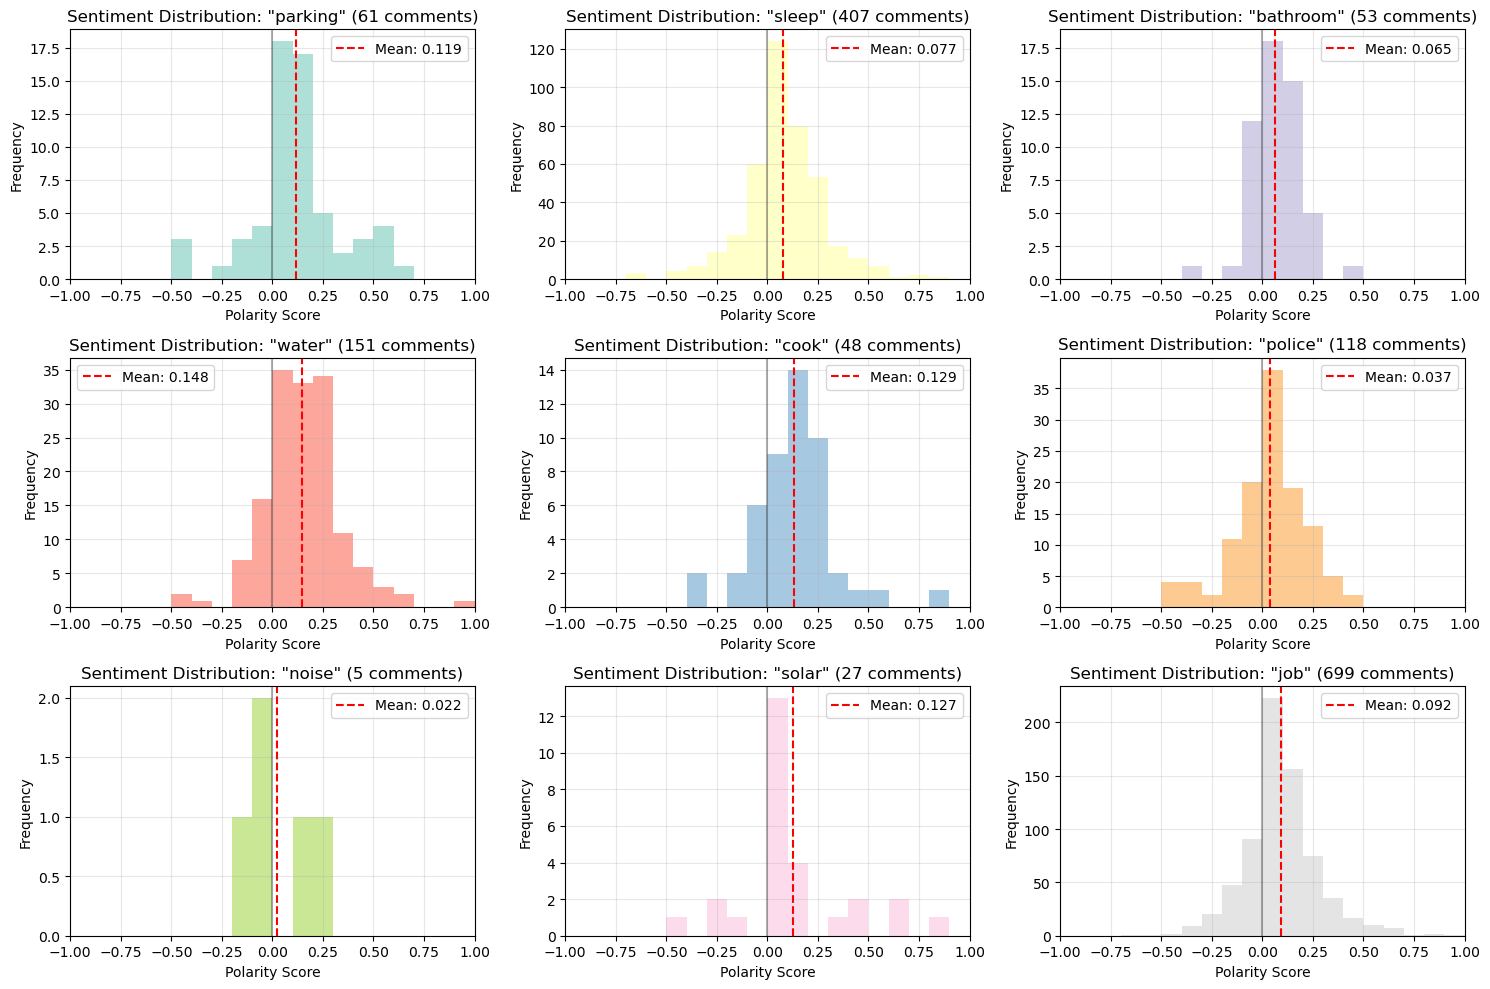

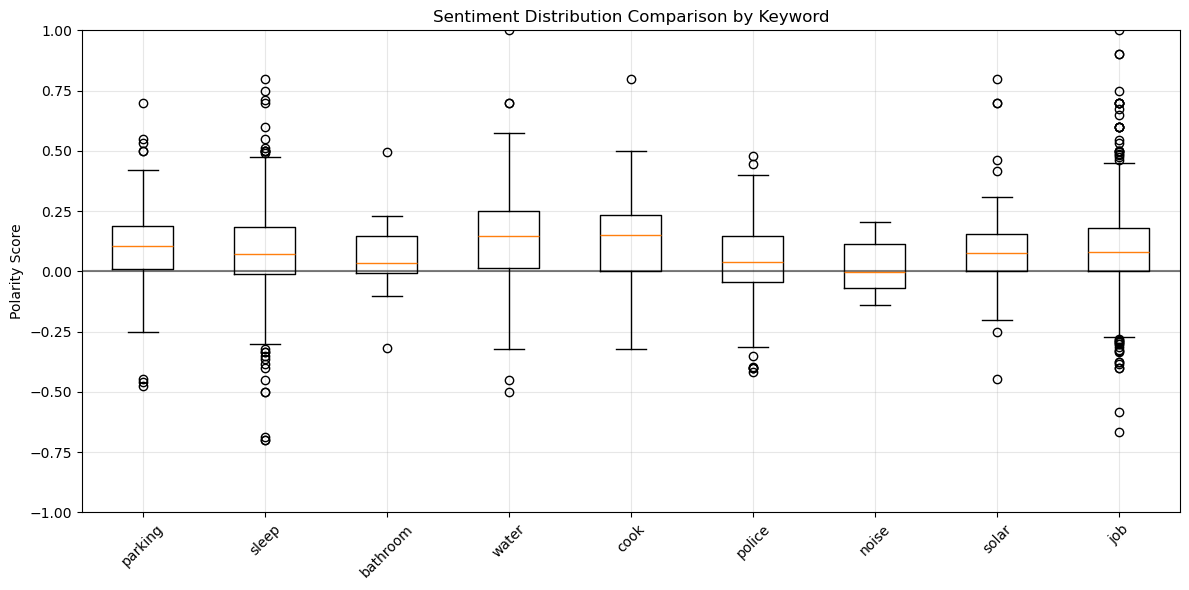

In [11]:
import matplotlib.pyplot as plt
import numpy as np


# Define keywords to analyze
keywords = ['parking', 'sleep', 'bathroom', 'water', 'cook', 'police', 'noise', 'solar', 'job']

# Function to find comments containing specific keywords
def get_sentiment_by_keyword(df_sentiment, keyword):
    mask = df_sentiment['comment'].str.contains(keyword, case=False, na=False)
    return df_sentiment[mask]['polarity']

# Collect sentiment data for each keyword
keyword_sentiments = {}
for keyword in keywords:
    sentiments = get_sentiment_by_keyword(df_sentiment, keyword)
    keyword_sentiments[keyword] = sentiments
    print(f"{keyword}: {len(sentiments)} comments found")

# Create subplot for each keyword
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
x_min, x_max = -1.0, 1.0  
bins = np.linspace(x_min, x_max, 21)  

for i, keyword in enumerate(keywords):
    sentiments = keyword_sentiments[keyword]
    
    if len(sentiments) > 0:
        # Create histogram with consistent bins and x-axis
        axes[i].hist(sentiments, bins=bins, alpha=0.7, color=plt.cm.Set3(i))
        axes[i].axvline(sentiments.mean(), color='red', linestyle='--', 
                       label=f'Mean: {sentiments.mean():.3f}')
        axes[i].set_title(f'Sentiment Distribution: "{keyword}" ({len(sentiments)} comments)')
        axes[i].set_xlabel('Polarity Score')
        axes[i].set_ylabel('Frequency')
        axes[i].set_xlim(x_min, x_max)  # Consistent x-axis range
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Add vertical line at 0 for reference
        axes[i].axvline(0, color='black', linestyle='-', alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, f'No comments found\nfor "{keyword}"', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'Sentiment Distribution: "{keyword}"')
        axes[i].set_xlim(x_min, x_max)  # Keep same x-axis even for empty plots
        axes[i].set_xlabel('Polarity Score')
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plot comparison with consistent y-axis
plt.figure(figsize=(12, 6))
sentiment_data = [keyword_sentiments[keyword] for keyword in keywords if len(keyword_sentiments[keyword]) > 0]
labels = [keyword for keyword in keywords if len(keyword_sentiments[keyword]) > 0]

if sentiment_data:
    plt.boxplot(sentiment_data, labels=labels)
    plt.title('Sentiment Distribution Comparison by Keyword')
    plt.ylabel('Polarity Score')
    plt.ylim(x_min, x_max)  # Consistent y-axis range
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No sentiment data found for any keywords")